# 🏨 Hotel Booking Demand: Who Cancels, and What It Costs

Two hotels in Portugal, a **City Hotel** (Lisbon) and a **Resort Hotel** (Algarve), recorded 119,390 bookings with arrival dates from July 1, 2015 to August 31, 2017. Each row is one booking, including bookings that were later canceled. The data was published by Antonio, Almeida & Nunes (2019), ["Hotel booking demand datasets," *Data in Brief* 22, 41–49](https://doi.org/10.1016/j.dib.2018.11.126).

This notebook uses `hotel_booking_cleaned.csv`, produced by `process-dataset.ipynb`. That step combined the arrival year, month, and day into one `arrival_date` column and dropped `market_segment`, `booking_changes`, `company`, `days_in_waiting_list`, `total_of_special_requests`, and the synthetic e-mail, phone, and credit card columns.

**Questions**

1. How often are bookings canceled, and how does that vary by hotel, season, and lead time?
2. Why do "Non Refund" bookings cancel *more* often than "No Deposit" bookings?
3. Do domestic (Portuguese) bookings and a guest's booking history predict cancellation?
4. Which columns *look* predictive but are only recorded at or after check-in (leakage)?
5. How does the average daily rate (ADR) move with the seasons, and how much booked room revenue do cancellations take away?

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', 50)

In [3]:
import calendar

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.templates['sans_serif'] = go.layout.Template(dict(layout=go.Layout(
    font_family='Helvetica, Inter, Arial, sans-serif')))
pio.templates.default = 'simple_white+sans_serif'

HOTEL_COLORS = {'City Hotel': '#222222', 'Resort Hotel': '#eb6834'}
HIGHLIGHT = '#222222'
GRAY = '#BBBBBB'
MONTH_ABBR = list(calendar.month_abbr)[1:]

Load the cleaned data. The original GitHub URL is kept in a comment so it is easy to switch back.

In [4]:
# Original source (switch back if you have network access):
# df = pd.read_csv('https://github.com/bdi475/datasets/raw/main/hotel_booking_cleaned.csv')
df = pd.read_csv('hotel_booking_cleaned.csv')

The cleaned file still carries a `name` column of synthetic (fake) guest names. It has no analytical value, so we drop it right away rather than display it.

In [5]:
df = df.drop(columns=['name'])

In [6]:
df

,hotel,is_canceled,lead_time,arrival_date,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,deposit_type,agent,customer_type,adr,required_car_parking_spaces,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015-07-01,0,0,2,0.0,0,BB,PRT,Direct,0,0,0,C,C,No Deposit,NaN,Transient,0.00,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015-07-01,0,0,2,0.0,0,BB,PRT,Direct,0,0,0,C,C,No Deposit,NaN,Transient,0.00,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015-07-01,0,1,1,0.0,0,BB,GBR,Direct,0,0,0,A,C,No Deposit,NaN,Transient,75.00,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015-07-01,0,1,1,0.0,0,BB,GBR,Corporate,0,0,0,A,A,No Deposit,304.0,Transient,75.00,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015-07-01,0,2,2,0.0,0,BB,GBR,TA/TO,0,0,0,A,A,No Deposit,240.0,Transient,98.00,0,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017-08-30,2,5,2,0.0,0,BB,BEL,TA/TO,0,0,0,A,A,No Deposit,394.0,Transient,96.14,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017-08-31,2,5,3,0.0,0,BB,FRA,TA/TO,0,0,0,E,E,No Deposit,9.0,Transient,225.43,0,Check-Out,2017-09-07
119387,City Hotel,0,34,2017-08-31,2,5,2,0.0,0,BB,DEU,TA/TO,0,0,0,D,D,No Deposit,9.0,Transient,157.71,0,Check-Out,2017-09-07
119388,City Hotel,0,109,2017-08-31,2,5,2,0.0,0,BB,GBR,TA/TO,0,0,0,A,A,No Deposit,89.0,Transient,104.40,0,Check-Out,2017-09-07


## 👀 At a Glance

A few quick facts before the main questions.

Longest lead time (days between booking and arrival), about two years:

In [7]:
df['lead_time'].max()

np.int64(737)

Bookings by guest country (ISO 3166-1 alpha-3 codes). Portugal (`PRT`) alone accounts for 48,590 bookings, about 41% of the total.

In [8]:
df['country'].value_counts()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
NCL        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64

Bookings where the assigned room type differs from the reserved room type. We come back to this column in the leakage section.

In [9]:
sum(df['reserved_room_type'] != df['assigned_room_type'])

14917

Bookings by arrival year. **2015 (July–December) and 2017 (January–August) are partial years**, so these counts are not comparable across years. 2016 is the only complete year.

In [10]:
df['arrival_date'] = pd.to_datetime(df['arrival_date'])
df['arrival_year'] = df['arrival_date'].dt.year

In [11]:
df.groupby(
    'arrival_year',
    as_index=False
).agg({
    'hotel': 'count'
})

,arrival_year,hotel
0,2015,21996
1,2016,56707
2,2017,40687


Average lead time by hotel:

In [12]:
df.groupby('hotel', as_index=False).agg({
    'lead_time': 'mean',
    
})

,hotel,lead_time
0,City Hotel,109.735724
1,Resort Hotel,92.675686


Repeat guests make up only about 3.2% of bookings:

In [13]:
df.value_counts('is_repeated_guest')

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64

In [14]:
3810 / 119390 * 100

3.191222045397437

Shape and column types. After dropping `name` and adding `arrival_year`, the frame has 25 columns.

In [15]:
df.shape

(119390, 25)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  str           
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date                    119390 non-null  datetime64[us]
 4   stays_in_weekend_nights         119390 non-null  int64         
 5   stays_in_week_nights            119390 non-null  int64         
 6   adults                          119390 non-null  int64         
 7   children                        119386 non-null  float64       
 8   babies                          119390 non-null  int64         
 9   meal                            119390 non-null  str           
 10  country                         118902 non-null  str           
 11

`children` has 4 missing values:

In [17]:
df['children'].isna().sum()

np.int64(4)

Bookings that required at least one car parking space. Most need one space; two bookings asked for eight.

In [18]:
df[df['required_car_parking_spaces'] > 0]['required_car_parking_spaces'].value_counts()

required_car_parking_spaces
1    7383
2      28
3       3
8       2
Name: count, dtype: int64

## 🧹 Data Quality Checks

Before analyzing cancellations, check two kinds of problems: columns that *are* the outcome in disguise, and implausible values.

In [19]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


In [20]:
df['nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['guests'] = df['adults'] + df['children'].fillna(0) + df['babies']

pd.Series({
    'ADR < 0': (df['adr'] < 0).sum(),
    'ADR = 0': (df['adr'] == 0).sum(),
    'ADR > 1,000': (df['adr'] > 1000).sum(),
    'Zero nights': (df['nights'] == 0).sum(),
    'Zero guests': (df['guests'] == 0).sum(),
    'Missing country': df['country'].isna().sum(),
    'Missing children': df['children'].isna().sum(),
}, name='bookings').to_frame()

,bookings
ADR < 0,1
ADR = 0,1959
"ADR > 1,000",1
Zero nights,715
Zero guests,180
Missing country,488
Missing children,4


In [21]:
df.query('adr < 0 or adr > 500')[['hotel', 'arrival_date', 'adr', 'nights', 'is_canceled']]

,hotel,arrival_date,adr,nights,is_canceled
14969,Resort Hotel,2017-03-05,-6.38,10,0
15083,Resort Hotel,2015-07-15,508.00,1,0
48515,City Hotel,2016-03-25,5400.00,1,1
111403,City Hotel,2017-05-09,510.00,1,0


**What we found and how we handle it**

- **`reservation_status` is the outcome restated.** Every `Canceled` and `No-Show` row has `is_canceled = 1`, and every `Check-Out` row has `is_canceled = 0`. `reservation_status_date` is the date of that final status (the cancellation date or the check-out date), so it is only known *after* the fact. Neither column can be used to predict cancellations. We use `reservation_status_date` only to measure *how far ahead* guests cancel.
- **ADR outliers.** One booking has a negative ADR (−6.38), and one canceled 1-night City Hotel booking has an ADR of 5,400 while the next-highest ADR is 510, so it is almost certainly an entry error. Another 1,959 bookings have an ADR of 0 (complimentary or package stays).
- **Empty stays.** 715 bookings have zero nights and 180 have zero guests.
- **Missing values.** 488 bookings have no country and 4 have no `children` count.

For the **cancellation analysis** we keep all 119,390 bookings, because the cancellation flag is valid even when ADR is odd. For the **revenue analysis** we drop the negative and the 5,400 ADR, zero-night stays, and zero-guest bookings (the `rev` table at the start of Part 2).

## Part 1: Cancellations

### 1️⃣ How often are bookings canceled?

In [22]:
print(f"Overall cancellation rate: {df['is_canceled'].mean():.1%}")

df.groupby('hotel', as_index=False).agg(
    bookings=('is_canceled', 'size'),
    canceled=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
)

Overall cancellation rate: 37.0%


,hotel,bookings,canceled,cancel_rate
0,City Hotel,79330,33102,0.417270
1,Resort Hotel,40060,11122,0.277634


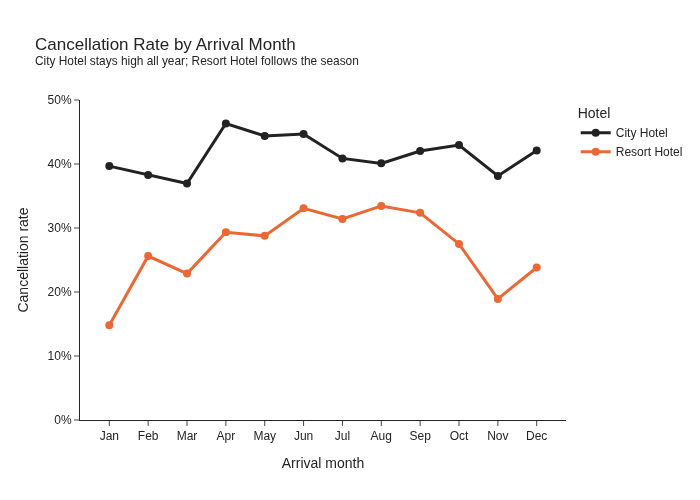

arrival_month,1,2,3,4,5,6,7,8,9,10,11,12
hotel,,,,,,,,,,,,
City Hotel,0.397,0.383,0.369,0.463,0.444,0.447,0.409,0.401,0.420,0.430,0.381,0.421
Resort Hotel,0.148,0.256,0.229,0.293,0.288,0.331,0.314,0.334,0.324,0.275,0.189,0.238


In [23]:
df['arrival_month'] = df['arrival_date'].dt.month

df_cancel_month = df.groupby(['hotel', 'arrival_month'], as_index=False).agg({
    'is_canceled': 'mean'
})

fig = px.line(
    df_cancel_month,
    x='arrival_month',
    y='is_canceled',
    color='hotel',
    color_discrete_map=HOTEL_COLORS,
    markers=True,
    title='Cancellation Rate by Arrival Month<br><sup>City Hotel stays high all year; Resort Hotel follows the season</sup>',
    labels={'arrival_month': 'Arrival month', 'is_canceled': 'Cancellation rate', 'hotel': 'Hotel'}
)
fig.update_traces(line_width=3, marker_size=8)
fig.update_layout(
    yaxis_tickformat='.0%',
    yaxis_range=[0, 0.5],
    xaxis=dict(tickmode='array', tickvals=list(range(1, 13)), ticktext=MONTH_ABBR)
)
fig.show()

df_cancel_month.pivot(index='arrival_month', columns='hotel', values='is_canceled').round(3).T

**37.0%** of all bookings were canceled: **41.7%** at the City Hotel versus **27.8%** at the Resort Hotel. The City Hotel's rate sits between 37% and 46% in every month. The Resort Hotel's rate is seasonal, from 14.8% for January arrivals to 33.4% for August arrivals.

### 2️⃣ Does booking further ahead mean more cancellations?

In [24]:
lead_bins = [-1, 7, 30, 90, 180, 365, df['lead_time'].max()]
lead_labels = ['0–7', '8–30', '31–90', '91–180', '181–365', '366+']
df['lead_band'] = pd.cut(df['lead_time'], bins=lead_bins, labels=lead_labels)

df_lead = df.groupby('lead_band', as_index=False, observed=True).agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean')
)
df_lead

,lead_band,bookings,cancel_rate
0,0–7,19746,0.096323
1,8–30,18960,0.278639
2,31–90,29553,0.376984
3,91–180,26439,0.447105
4,181–365,21544,0.554540
5,366+,3148,0.676620


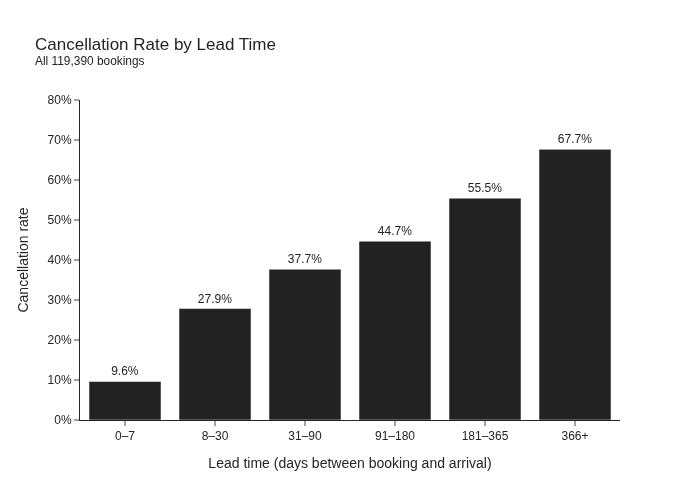

In [25]:
fig = px.bar(
    df_lead,
    x='lead_band',
    y='cancel_rate',
    text='cancel_rate',
    title='Cancellation Rate by Lead Time<br><sup>All 119,390 bookings</sup>',
    labels={'lead_band': 'Lead time (days between booking and arrival)', 'cancel_rate': 'Cancellation rate'}
)
fig.update_traces(marker_color=HIGHLIGHT, texttemplate='%{text:.1%}', textposition='outside')
fig.update_layout(yaxis_tickformat='.0%', yaxis_range=[0, 0.8])
fig.show()

The pattern is strong and monotonic: **9.6%** of bookings made within a week of arrival were canceled, rising to **67.7%** of bookings made more than a year ahead. A long lead time gives guests more time for plans to change and more time to find a better deal. As the next section shows, though, part of this curve comes from one unusual group of bookings.

### 3️⃣ The "Non Refund" paradox

A non-refundable deposit should make guests the *least* likely to cancel. Here it is the opposite.

In [26]:
df.groupby('deposit_type', as_index=False).agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean'),
    median_lead_time=('lead_time', 'median')
)

,deposit_type,bookings,cancel_rate,median_lead_time
0,No Deposit,104641,0.283770,56.0
1,Non Refund,14587,0.993624,183.0
2,Refundable,162,0.222222,169.0


**99.4%** of "Non Refund" bookings were canceled, versus **28.4%** of "No Deposit" bookings. Before concluding that deposits *cause* cancellations, look at *who* these bookings are. The comparison below also flags rows that are exact copies of at least one other row, which is what a block of identical rooms booked together looks like.

In [27]:
df['identical_copy'] = df.duplicated(keep=False)

df_profile = (
    df.query('deposit_type != "Refundable"')
      .assign(
          from_prt=lambda x: x['country'] == 'PRT',
          via_travel_agent=lambda x: x['distribution_channel'] == 'TA/TO',
          lead_over_180=lambda x: x['lead_time'] > 180,
      )
      .groupby('deposit_type', as_index=False)
      .agg({
          'is_canceled': 'mean',
          'from_prt': 'mean',
          'via_travel_agent': 'mean',
          'lead_over_180': 'mean',
          'identical_copy': 'mean'
      })
)
df_profile

,deposit_type,is_canceled,from_prt,via_travel_agent,lead_over_180,identical_copy
0,No Deposit,0.283770,0.328418,0.804264,0.164228,0.264485
1,Non Refund,0.993624,0.971824,0.935833,0.512717,0.981902


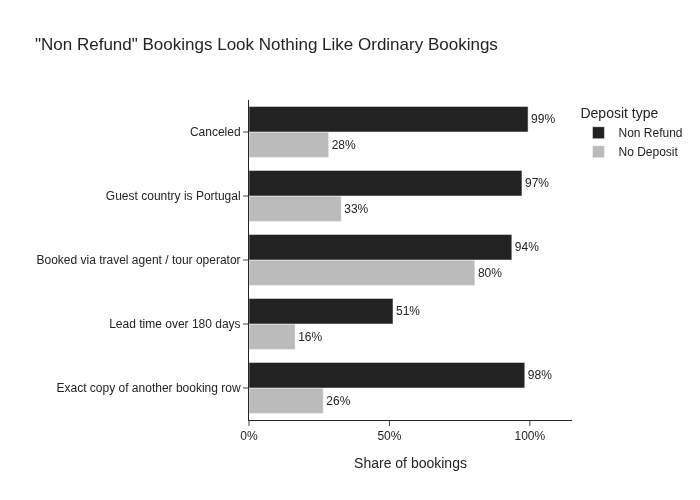

In [28]:
trait_labels = {
    'is_canceled': 'Canceled',
    'from_prt': 'Guest country is Portugal',
    'via_travel_agent': 'Booked via travel agent / tour operator',
    'lead_over_180': 'Lead time over 180 days',
    'identical_copy': 'Exact copy of another booking row'
}

df_profile_long = df_profile.melt(id_vars='deposit_type', var_name='trait', value_name='share')
df_profile_long['trait'] = df_profile_long['trait'].map(trait_labels)

fig = px.bar(
    df_profile_long,
    x='share',
    y='trait',
    color='deposit_type',
    barmode='group',
    orientation='h',
    text='share',
    color_discrete_map={'Non Refund': HIGHLIGHT, 'No Deposit': GRAY},
    category_orders={'trait': list(trait_labels.values()), 'deposit_type': ['No Deposit', 'Non Refund']},
    title='"Non Refund" Bookings Look Nothing Like Ordinary Bookings',
    labels={'share': 'Share of bookings', 'trait': '', 'deposit_type': 'Deposit type'}
)
fig.update_traces(texttemplate='%{text:.0%}', textposition='outside')
fig.update_layout(xaxis_tickformat='.0%', xaxis_range=[0, 1.15], height=500, legend_traceorder='reversed')
fig.show()

They were also canceled **in bulk**. The five busiest cancellation dates for Non Refund bookings each wiped out hundreds of bookings at once:

In [29]:
(
    df.query('deposit_type == "Non Refund" and is_canceled == 1')
      .groupby('reservation_status_date', as_index=False)
      .agg(
          cancellations=('hotel', 'size'),
          hotels=('hotel', 'nunique'),
          distinct_arrival_dates=('arrival_date', 'nunique')
      )
      .sort_values('cancellations', ascending=False)
      .head(5)
)

,reservation_status_date,cancellations,hotels,distinct_arrival_dates
66,2015-10-21,1357,1,53
195,2016-11-25,651,1,18
0,2015-01-01,540,1,27
106,2016-01-18,511,2,11
19,2015-07-02,450,1,15


The cleaning step dropped `market_segment`, which turns out to be the most informative column here. The raw file has the same rows in the same order, so we can borrow it for a cross-check.

In [30]:
raw = pd.read_csv('hotel_booking.csv', usecols=['lead_time', 'adr', 'market_segment'])
assert (raw['lead_time'].values == df['lead_time'].values).all()
assert np.allclose(raw['adr'].values, df['adr'].values)

pd.crosstab(raw['market_segment'], df['deposit_type'], normalize='columns').round(3)

deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,0.002,0.000,0.000
Complementary,0.007,0.000,0.000
Corporate,0.047,0.023,0.025
Direct,0.120,0.001,0.037
Groups,0.100,0.629,0.802
Offline TA/TO,0.184,0.343,0.025
Online TA,0.539,0.004,0.111
Undefined,0.000,0.000,0.000


Removing the Non Refund rows also changes the lead-time story from Section 2:

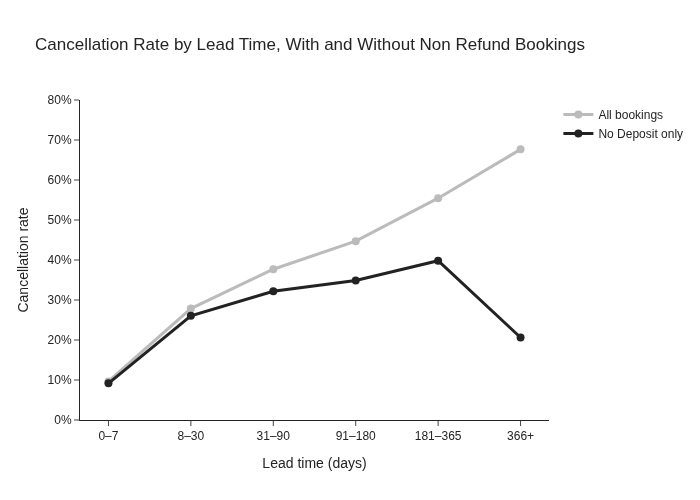

subset,All bookings,No Deposit only
lead_band,,
0–7,0.096,0.092
8–30,0.279,0.260
31–90,0.377,0.322
91–180,0.447,0.349
181–365,0.555,0.398
366+,0.677,0.206


In [31]:
df_lead_compare = pd.concat([
    df.assign(subset='All bookings'),
    df.query('deposit_type == "No Deposit"').assign(subset='No Deposit only')
]).groupby(['subset', 'lead_band'], as_index=False, observed=True).agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean')
)

fig = px.line(
    df_lead_compare,
    x='lead_band',
    y='cancel_rate',
    color='subset',
    markers=True,
    color_discrete_map={'All bookings': GRAY, 'No Deposit only': HIGHLIGHT},
    title='Cancellation Rate by Lead Time, With and Without Non Refund Bookings',
    labels={'lead_band': 'Lead time (days)', 'cancel_rate': 'Cancellation rate', 'subset': ''}
)
fig.update_traces(line_width=3, marker_size=8)
fig.update_layout(yaxis_tickformat='.0%', yaxis_range=[0, 0.8])
fig.show()

df_lead_compare.pivot(index='lead_band', columns='subset', values='cancel_rate').round(3)

In [32]:
df_hotel_nr = (
    df.assign(is_non_refund=lambda x: x['deposit_type'] == 'Non Refund')
      .groupby('hotel', as_index=False)
      .agg(
          non_refund_share=('is_non_refund', 'mean'),
          cancel_rate_all=('is_canceled', 'mean')
      )
      .merge(
          df.query('deposit_type != "Non Refund"')
            .groupby('hotel', as_index=False)
            .agg(cancel_rate_excl_non_refund=('is_canceled', 'mean')),
          on='hotel'
      )
)
df_hotel_nr

,hotel,non_refund_share,cancel_rate_all,cancel_rate_excl_non_refund
0,City Hotel,0.162208,0.417270,0.304806
1,Resort Hotel,0.042911,0.277634,0.247046


**What is going on?** The Non Refund bookings are a distinct population:

- **97%** list Portugal as the guest country (vs. 33% of No Deposit bookings), and **94%** came through travel agents / tour operators.
- **51%** were made more than 180 days ahead (vs. 16%), and **98%** are exact copies of at least one other row (vs. 26%), i.e., blocks of identical rooms.
- They were canceled in batches: **1,357** bookings spanning 53 arrival dates were canceled on a single day (2015-10-21).
- In the raw file, **62.9%** are in the `Groups` market segment and **34.3%** in `Offline TA/TO`.

This is consistent with **group or tour-operator block reservations** (allotments) that were released in bulk when they did not fill. Whether a deposit was actually collected on these rooms cannot be verified from the data. The label "Non Refund" describes the booking's terms on paper, not necessarily money received.

**Why it matters**

1. **Don't read the label as a cause.** Deposit type is confounded with *booking type*. The data does not show that non-refundable rates make guests cancel.
2. **These rows distort other patterns.** For No Deposit bookings, the lead-time curve rises from 9.2% to 39.8% and then *falls* to 20.6% for 366+ days. The steep 67.7% at the top end of the overall curve was mostly block bookings.
3. **They inflate the City Hotel's rate.** 16.2% of City Hotel bookings are Non Refund. Without them, its cancellation rate drops from 41.7% to 30.5% (Resort Hotel: 27.8% to 24.7%).
4. **Cleaning choices matter.** Dropping `market_segment` during cleaning removed the column that best explains the anomaly.

### 4️⃣ Do domestic bookings cancel more often?

In [33]:
df['guest_origin'] = np.where(df['country'] == 'PRT', 'Portugal (PRT)', 'Other countries')

df_origin = pd.concat([
    df.assign(subset='All bookings'),
    df.query('deposit_type == "No Deposit"').assign(subset='No Deposit only')
]).groupby(['subset', 'guest_origin'], as_index=False).agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean')
)
df_origin

,subset,guest_origin,bookings,cancel_rate
0,All bookings,Other countries,70800,0.235946
1,All bookings,Portugal (PRT),48590,0.566351
2,No Deposit only,Other countries,70275,0.232487
3,No Deposit only,Portugal (PRT),34366,0.388640


In [34]:
df.query('deposit_type == "No Deposit"').pivot_table(
    index='hotel', columns='guest_origin', values='is_canceled', aggfunc='mean'
).round(3)

guest_origin,Other countries,Portugal (PRT)
hotel,,
City Hotel,0.267,0.404
Resort Hotel,0.157,0.371


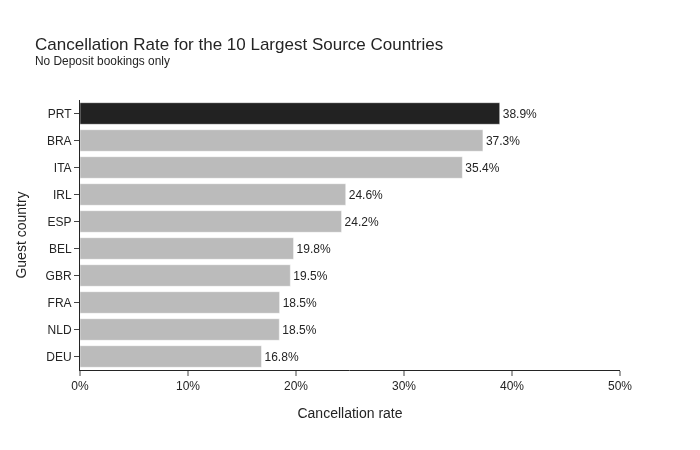

In [35]:
top_countries = df['country'].value_counts().head(10).index

df_country = (
    df.query('deposit_type == "No Deposit" and country in @top_countries')
      .groupby('country', as_index=False)
      .agg(bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean'))
      .sort_values('cancel_rate')
)

fig = px.bar(
    df_country,
    x='cancel_rate',
    y='country',
    orientation='h',
    text='cancel_rate',
    title='Cancellation Rate for the 10 Largest Source Countries<br><sup>No Deposit bookings only</sup>',
    labels={'cancel_rate': 'Cancellation rate', 'country': 'Guest country'}
)
fig.update_traces(
    marker_color=[HIGHLIGHT if c == 'PRT' else GRAY for c in df_country['country']],
    texttemplate='%{text:.1%}',
    textposition='outside'
)
fig.update_layout(xaxis_tickformat='.0%', xaxis_range=[0, 0.5], height=450)
fig.show()

Across all bookings, **56.6%** of Portuguese bookings were canceled versus **23.6%** for everyone else. Much of that gap is the Non Refund block bookings: only 34,366 of the 48,590 PRT bookings are No Deposit. Among No Deposit bookings, the gap narrows but stays large: **38.9% vs. 23.2%**, and it holds in both hotels (City 40.4% vs. 26.7%; Resort 37.1% vs. 15.7%).

Portugal has the highest rate among the 10 largest source countries, but Brazil (37.3%) and Italy (35.4%) are close, so being domestic is not the only story. Plausible explanations include easier, lower-commitment booking for nearby guests (for example, booking a fallback hotel for a short trip). One caveat to keep in mind: guest nationality is often confirmed at check-in, so `country` may be less reliable for bookings that never arrived. This dataset cannot tell us how much that matters.

### 5️⃣ Does a guest's booking history predict cancellation?

In [36]:
df['prev_cancel_band'] = pd.cut(
    df['previous_cancellations'], bins=[-1, 0, 1, 5, df['previous_cancellations'].max()],
    labels=['0', '1', '2–5', '6+']
)
df['prev_stays_band'] = pd.cut(
    df['previous_bookings_not_canceled'], bins=[-1, 0, 1, 5, df['previous_bookings_not_canceled'].max()],
    labels=['0', '1', '2–5', '6+']
)

df_history = pd.concat({
    'Repeat guest': df.groupby('is_repeated_guest').agg(
        bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')),
    'Previous stays (not canceled)': df.groupby('prev_stays_band', observed=True).agg(
        bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')),
    'Previous cancellations': df.groupby('prev_cancel_band', observed=True).agg(
        bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')),
})
df_history.round(3)

bookings  cancel_rate
Repeat guest                  0      115580        0.378
                              1        3810        0.145
Previous stays (not canceled) 0      115770        0.380
                              1        1542        0.051
                              2–5      1323        0.054
                              6+        755        0.065
Previous cancellations        0      112906        0.339
                              1        6051        0.944
                              2–5       231        0.290
                              6+        202        0.797

In [37]:
df.assign(has_prev_cancel=lambda x: x['previous_cancellations'] > 0).groupby(
    'arrival_year', as_index=False
).agg(
    bookings=('has_prev_cancel', 'size'),
    share_with_prev_cancel=('has_prev_cancel', 'mean')
)

,arrival_year,bookings,share_with_prev_cancel
0,2015,21996,0.201628
1,2016,56707,0.031231
2,2017,40687,0.006833


In [38]:
one_prev_cancel = df.query('previous_cancellations == 1')

print(f'Bookings with exactly 1 previous cancellation: {len(one_prev_cancel):,}')
print(f"  Non Refund deposit: {(one_prev_cancel['deposit_type'] == 'Non Refund').mean():.1%}")
print(f"  Guest country PRT:  {(one_prev_cancel['country'] == 'PRT').mean():.1%}")

Bookings with exactly 1 previous cancellation: 6,051
  Non Refund deposit: 58.4%
  Guest country PRT:  95.7%


**Positive history is a strong, sensible signal.** Repeat guests cancel **14.5%** of the time versus **37.8%** for first-timers, and guests with at least one previous completed stay cancel only **5–7%** of the time.

**`previous_cancellations` needs care.** One previous cancellation goes with a **94.4%** cancellation rate (6,051 bookings), but 2–5 previous cancellations go with only **29.0%**, so the relationship is not monotonic. These bookings are also concentrated in the earliest arrivals: **20.2%** of 2015 arrivals have a previous cancellation, versus **3.1%** in 2016 and **0.7%** in 2017. That is the opposite of what we would expect if the column counted each guest's growing history. Of the bookings with exactly one previous cancellation, **58.4%** are Non Refund and **95.7%** are from Portugal, so this column largely re-detects the same block bookings from Section 3.

### 6️⃣ Leakage traps: room reassignment and parking

Two columns look like excellent predictors of *not* canceling. Check when they get recorded.

In [39]:
df['room_changed'] = df['reserved_room_type'] != df['assigned_room_type']
df['has_parking'] = df['required_car_parking_spaces'] > 0

df_leak = pd.concat({
    'Assigned room type': df.groupby('room_changed').agg(
        bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')
    ).rename(index={False: 'Same as reserved', True: 'Different from reserved'}),
    'Car parking': df.groupby('has_parking').agg(
        bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')
    ).rename(index={False: 'None required', True: '1+ spaces required'}),
})
df_leak.round(3)

bookings  cancel_rate
Assigned room type Same as reserved           104473        0.416
                   Different from reserved     14917        0.054
Car parking        None required              111974        0.395
                   1+ spaces required           7416        0.000

In [40]:
df.groupby('reservation_status', as_index=False).agg(
    bookings=('room_changed', 'size'),
    share_room_changed=('room_changed', 'mean'),
    share_with_parking=('has_parking', 'mean')
)

,reservation_status,bookings,share_room_changed,share_with_parking
0,Canceled,43017,0.013808,0.000000
1,Check-Out,75166,0.187784,0.098662
2,No-Show,1207,0.172328,0.000000


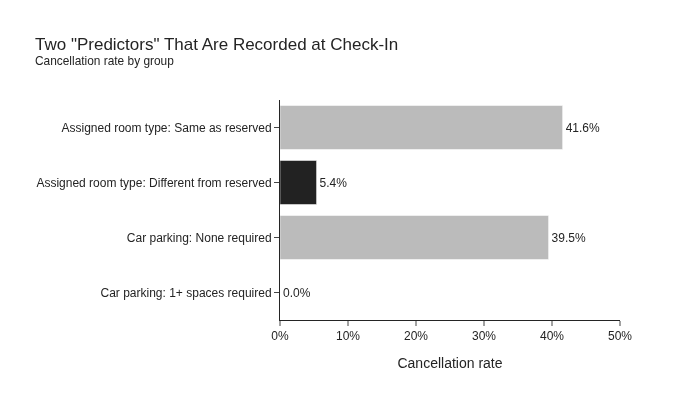

In [41]:
df_leak_plot = df_leak.reset_index(names=['column', 'value'])
df_leak_plot['label'] = df_leak_plot['column'] + ': ' + df_leak_plot['value']

fig = px.bar(
    df_leak_plot,
    x='cancel_rate',
    y='label',
    orientation='h',
    text='cancel_rate',
    title='Two "Predictors" That Are Recorded at Check-In<br><sup>Cancellation rate by group</sup>',
    labels={'cancel_rate': 'Cancellation rate', 'label': ''}
)
fig.update_traces(
    marker_color=[HIGHLIGHT if v in ('Different from reserved', '1+ spaces required') else GRAY
                  for v in df_leak_plot['value']],
    texttemplate='%{text:.1%}',
    textposition='outside'
)
fig.update_layout(xaxis_tickformat='.0%', xaxis_range=[0, 0.5], yaxis_autorange='reversed', height=400)
fig.show()

- **Room reassignment:** bookings whose assigned room differs from the reserved room were canceled only **5.4%** of the time, versus **41.6%** otherwise. But a different room is assigned in **18.8%** of check-outs and only **1.4%** of cancellations. Rooms are typically (re)assigned when the guest arrives, so a booking that is canceled never reaches that step. The "effect" runs backwards: *not canceling* causes the room change, not the other way around.
- **Parking:** **none** of the 7,416 bookings with a parking space were canceled. Parking needs appear to be recorded at arrival.

Both columns are fine for describing stays, but a model that predicts cancellations *at booking time* must exclude them, along with `reservation_status` and `reservation_status_date`.

### 7️⃣ A simple, honest cancellation model

How well can cancellations be predicted using only what is known at booking time? We fit a logistic regression on arrivals before 2017 and test it on 2017 arrivals (a time-based split, closer to how a hotel would use it). Then we compare feature sets, including one that adds the two leaky columns.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_model = df.query('adr >= 0 and adr < 1000').assign(
    children=lambda x: x['children'].fillna(0),
    is_prt=lambda x: (x['country'] == 'PRT').astype(int),
    has_agent=lambda x: x['agent'].notna().astype(int),
    arrival_month=lambda x: x['arrival_month'].astype(str),
    room_changed=lambda x: x['room_changed'].astype(int),
    has_parking=lambda x: x['has_parking'].astype(int),
)
train = df_model[df_model['arrival_date'] < '2017-01-01']
test = df_model[df_model['arrival_date'] >= '2017-01-01']

numeric_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
    'is_prt', 'has_agent'
]
categorical_features = [
    'hotel', 'arrival_month', 'meal', 'distribution_channel', 'reserved_room_type',
    'deposit_type', 'customer_type'
]
block_fingerprints = ['deposit_type', 'is_prt', 'previous_cancellations']

feature_sets = {
    'Lead time only': (['lead_time'], []),
    'Lead time + deposit type': (['lead_time'], ['deposit_type']),
    'All booking-time features': (numeric_features, categorical_features),
    'Booking-time, no block fingerprints': (
        [c for c in numeric_features if c not in block_fingerprints],
        [c for c in categorical_features if c not in block_fingerprints]
    ),
    'Booking-time + leaky columns': (
        numeric_features + ['room_changed', 'has_parking'], categorical_features
    ),
}

def fit_model(numeric, categorical):
    preprocess = ColumnTransformer([
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ])
    model = make_pipeline(preprocess, LogisticRegression(max_iter=2000))
    model.fit(train[numeric + categorical], train['is_canceled'])
    return model

results = []
models = {}
for name, (numeric, categorical) in feature_sets.items():
    model = fit_model(numeric, categorical)
    prob = model.predict_proba(test[numeric + categorical])[:, 1]
    models[name] = model
    results.append({
        'feature_set': name,
        'test_auc': roc_auc_score(test['is_canceled'], prob),
        'test_accuracy': accuracy_score(test['is_canceled'], prob >= 0.5),
    })

print(f'Train: {len(train):,} bookings | Test (2017 arrivals): {len(test):,} bookings')
print(f"Baseline accuracy (always predict 'not canceled'): {1 - test['is_canceled'].mean():.3f}")
pd.DataFrame(results).round(3)

Train: 78,702 bookings | Test (2017 arrivals): 40,686 bookings
Baseline accuracy (always predict 'not canceled'): 0.613


,feature_set,test_auc,test_accuracy
0,Lead time only,0.655,0.617
1,Lead time + deposit type,0.726,0.702
2,All booking-time features,0.800,0.733
3,"Booking-time, no block fingerprints",0.710,0.674
4,Booking-time + leaky columns,0.830,0.744


In [43]:
honest_model = models['All booking-time features']
coefficients = pd.Series(
    honest_model[-1].coef_[0],
    index=honest_model[0].get_feature_names_out()
).sort_values()

pd.concat([coefficients.head(5), coefficients.tail(5)]).round(2).to_frame('coefficient')

,coefficient
cat__deposit_type_Refundable,-1.57
cat__deposit_type_No Deposit,-1.53
cat__meal_Undefined,-0.75
num__previous_bookings_not_canceled,-0.72
cat__distribution_channel_Direct,-0.55
cat__meal_SC,0.72
cat__customer_type_Transient,0.76
num__is_prt,0.78
num__previous_cancellations,2.42
cat__deposit_type_Non Refund,3.05


- Lead time alone reaches an AUC of **0.655** on 2017 arrivals. Using all booking-time features lifts it to **0.80**, and accuracy rises from a 61.3% baseline to **73.3%**.
- The two largest coefficients belong to **Non Refund** deposits and **previous cancellations**, the block-booking fingerprints. Without them (and the PRT flag) AUC falls to **0.710**, so much of the model's skill comes from spotting tour-operator blocks rather than individual guest behavior.
- Adding the leaky columns (room changed, parking) raises AUC to **0.83**. That lift would vanish in production, because room assignment and parking are not known when the booking is made. A model evaluated with them looks better than it really is.

## Part 2: Revenue

From here on we use `rev`, a copy of the bookings that excludes the ADR errors, zero-night stays, and zero-guest bookings. ADR is the average daily rate: lodging revenue divided by the number of nights.

In [44]:
rev = df.query('adr >= 0 and adr < 1000 and nights > 0 and guests > 0').copy()
rev['room_revenue'] = rev['adr'] * rev['nights']

print(f'Bookings removed for the revenue analysis: {len(df) - len(rev):,}')

Bookings removed for the revenue analysis: 827


### 8️⃣ How seasonal are room rates?

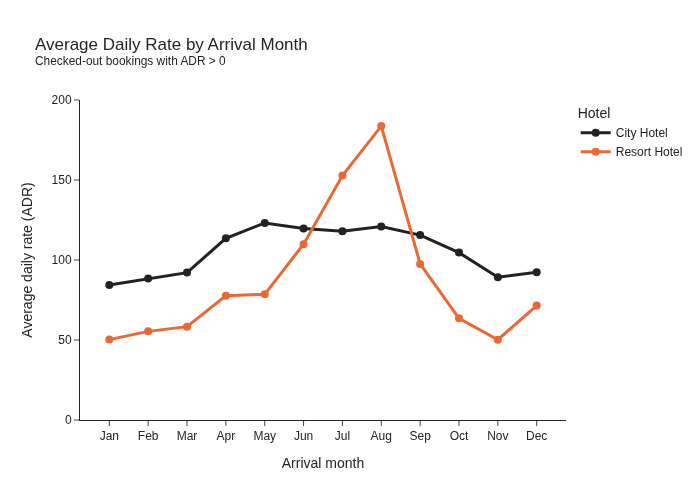

arrival_month,1,2,3,4,5,6,7,8,9,10,11,12
hotel,,,,,,,,,,,,
City Hotel,84.4,88.4,92.1,113.5,123.2,119.7,118.0,121.0,115.6,104.6,89.2,92.3
Resort Hotel,50.2,55.4,58.3,77.6,78.5,109.9,152.8,183.7,97.6,63.6,50.2,71.5


In [45]:
df_adr_month = rev.query('is_canceled == 0 and adr > 0').groupby(
    ['hotel', 'arrival_month'], as_index=False
).agg({'adr': 'mean'})

fig = px.line(
    df_adr_month,
    x='arrival_month',
    y='adr',
    color='hotel',
    color_discrete_map=HOTEL_COLORS,
    markers=True,
    title='Average Daily Rate by Arrival Month<br><sup>Checked-out bookings with ADR > 0</sup>',
    labels={'arrival_month': 'Arrival month', 'adr': 'Average daily rate (ADR)', 'hotel': 'Hotel'}
)
fig.update_traces(line_width=3, marker_size=8)
fig.update_layout(
    yaxis_range=[0, 200],
    xaxis=dict(tickmode='array', tickvals=list(range(1, 13)), ticktext=MONTH_ABBR)
)
fig.show()

df_adr_month.pivot(index='arrival_month', columns='hotel', values='adr').round(1).T

In [46]:
rev.query('is_canceled == 0 and adr > 0').pivot_table(
    index='hotel', columns='arrival_year', values='adr', aggfunc='mean'
).round(1)

arrival_year,2015,2016,2017
hotel,,,
City Hotel,92.1,106.4,118.7
Resort Hotel,92.2,86.1,103.5


The **Resort Hotel** is a summer property: its average ADR climbs from **50.2** for January and November arrivals to **183.7** in August, a 3.7× swing. The **City Hotel** is much steadier, from **84.4** in January to a peak of **123.2** in May. The Resort is cheaper than the City Hotel for most of the year but far pricier in July and August.

Caveat: rates rose year over year (the City Hotel's average went from 92.1 in 2015 to 118.7 in 2017), and July–August are the only months observed in all three years. Monthly averages pooled across years therefore mix in some of that trend.

### 9️⃣ Weekend vs. weeknight stays

In [47]:
stays = rev.query('is_canceled == 0').assign(
    stay_type=lambda x: np.select(
        [x['stays_in_week_nights'] == 0, x['stays_in_weekend_nights'] == 0],
        ['Weekend only', 'Weeknights only'],
        default='Spans both'
    )
)

df_stays = stays.groupby('hotel', as_index=False).agg({
    'nights': 'mean',
    'stays_in_weekend_nights': 'sum',
    'stays_in_week_nights': 'sum'
})
df_stays['weekend_share_of_nights'] = df_stays['stays_in_weekend_nights'] / (
    df_stays['stays_in_weekend_nights'] + df_stays['stays_in_week_nights'])
df_stays[['hotel', 'nights', 'weekend_share_of_nights']].round(3)

,hotel,nights,weekend_share_of_nights
0,City Hotel,2.934,0.274
1,Resort Hotel,4.196,0.274


In [48]:
stays.groupby(['hotel', 'stay_type'], as_index=False).agg(
    bookings=('adr', 'size'),
    avg_nights=('nights', 'mean'),
    avg_adr=('adr', 'mean')
).assign(share=lambda x: x['bookings'] / x.groupby('hotel')['bookings'].transform('sum')).round(3)

,hotel,stay_type,bookings,avg_nights,avg_adr,share
0,City Hotel,Spans both,21434,3.962,106.924,0.468
1,City Hotel,Weekend only,3173,1.335,104.765,0.069
2,City Hotel,Weeknights only,21226,2.135,106.583,0.463
3,Resort Hotel,Spans both,16116,6.041,98.808,0.564
4,Resort Hotel,Weekend only,1877,1.210,80.453,0.066
5,Resort Hotel,Weeknights only,10562,1.911,83.680,0.370


Resort stays are longer (**4.20** nights vs. **2.93**), but in both hotels weekend nights make up about **27.4%** of nights stayed, slightly *below* the 28.6% (2 of 7) we would see if nights were spread evenly across the week. Neither hotel is a weekend-getaway property on average. Weekend-only stays are rare (about 7% of stays at both hotels). At the Resort, stays that span both weekdays and a weekend command the highest ADR (98.8 vs. 80.5 for weekend-only). That most likely reflects longer summer holidays rather than a weekend premium.

### 🔟 How much booked revenue do cancellations take away?

We measure booked room revenue as `adr × nights`. This is a **gross** measure. Some canceled rooms were surely resold, and some deposits may have been kept, so the true loss is smaller.

In [49]:
rev['canceled_revenue'] = rev['room_revenue'] * rev['is_canceled']

df_rev_hotel = rev.groupby('hotel', as_index=False).agg({
    'room_revenue': 'sum',
    'canceled_revenue': 'sum'
})
df_rev_hotel.loc[len(df_rev_hotel)] = ['Both hotels', rev['room_revenue'].sum(), rev['canceled_revenue'].sum()]
df_rev_hotel['canceled_share'] = df_rev_hotel['canceled_revenue'] / df_rev_hotel['room_revenue']
df_rev_hotel.round(3)

,hotel,room_revenue,canceled_revenue,canceled_share
0,City Hotel,25265001.78,10879659.78,0.431
1,Resort Hotel,17443811.37,5842177.34,0.335
2,Both hotels,42708813.15,16721837.12,0.392


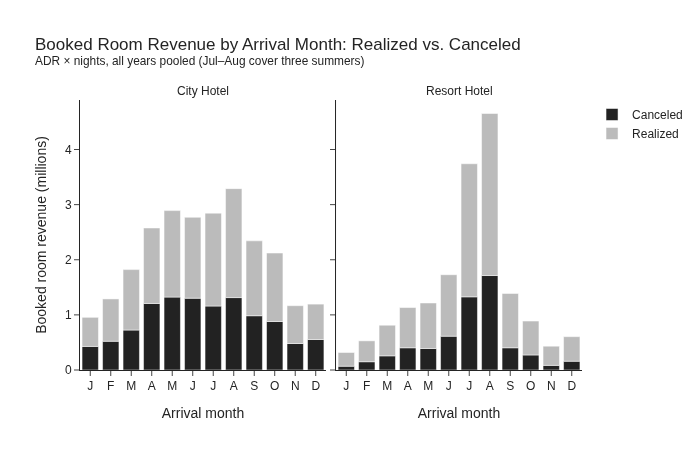

In [50]:
df_rev_month = (
    rev.assign(status=lambda x: np.where(x['is_canceled'] == 1, 'Canceled', 'Realized'))
       .groupby(['hotel', 'arrival_month', 'status'], as_index=False)
       .agg({'room_revenue': 'sum'})
)
df_rev_month['room_revenue_m'] = df_rev_month['room_revenue'] / 1e6

fig = px.bar(
    df_rev_month,
    x='arrival_month',
    y='room_revenue_m',
    color='status',
    facet_col='hotel',
    color_discrete_map={'Canceled': HIGHLIGHT, 'Realized': GRAY},
    category_orders={'status': ['Canceled', 'Realized']},
    title='Booked Room Revenue by Arrival Month: Realized vs. Canceled<br><sup>ADR × nights, all years pooled (Jul–Aug cover three summers)</sup>',
    labels={'arrival_month': 'Arrival month', 'room_revenue_m': 'Booked room revenue (millions)', 'status': ''}
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig.update_xaxes(tickmode='array', tickvals=list(range(1, 13)), ticktext=[m[0] for m in MONTH_ABBR])
fig.update_layout(height=450)
fig.show()

In [51]:
canceled = rev.query('is_canceled == 1').assign(
    days_before_arrival=lambda x: (x['arrival_date'] - pd.to_datetime(x['reservation_status_date'])).dt.days
)
canceled['cancel_timing'] = pd.cut(
    canceled['days_before_arrival'], bins=[-1, 7, 30, 90, canceled['days_before_arrival'].max()],
    labels=['0–7 days', '8–30 days', '31–90 days', '91+ days']
)

df_timing = canceled.groupby('cancel_timing', as_index=False, observed=True).agg(
    cancellations=('is_canceled', 'size'),
    canceled_revenue=('canceled_revenue', 'sum')
)
df_timing['share_of_cancellations'] = df_timing['cancellations'] / df_timing['cancellations'].sum()
df_timing['share_of_canceled_revenue'] = df_timing['canceled_revenue'] / df_timing['canceled_revenue'].sum()
df_timing.round(3)

,cancel_timing,cancellations,canceled_revenue,share_of_cancellations,share_of_canceled_revenue
0,0–7 days,6299,1981897.65,0.143,0.119
1,8–30 days,9366,3622761.21,0.212,0.217
2,31–90 days,12966,4971107.48,0.294,0.297
3,91+ days,15544,6146070.78,0.352,0.368


In [52]:
canceled.groupby('deposit_type', as_index=False).agg(
    cancellations=('is_canceled', 'size'),
    canceled_revenue=('canceled_revenue', 'sum'),
    median_days_before_arrival=('days_before_arrival', 'median')
).round(0)

,deposit_type,cancellations,canceled_revenue,median_days_before_arrival
0,No Deposit,29646,13102902.0,35.0
1,Non Refund,14493,3598937.0,102.0
2,Refundable,36,19998.0,4.0


- Of **42.7 million** in booked room revenue, **16.7 million (39.2%)** belonged to bookings that were canceled: **43.1%** at the City Hotel and **33.5%** at the Resort Hotel. Every month's arrivals lose a large slice. July and August look biggest partly because they are the only months observed in three summers (2015–2017).
- **3.6 million** of the canceled revenue comes from Non Refund bookings. If those deposits were actually collected, that part was not lost, which is another reason to treat the label carefully.
- Timing matters for resale. Only **14.3%** of cancellations (**11.9%** of canceled revenue) came within 7 days of arrival, the hardest rooms to resell. Most cancellations arrive weeks or months ahead: the median No Deposit cancellation came 35 days before arrival, and the median Non Refund cancellation came 102 days before.

## Key Findings

- **Cancellations are common and uneven.** 37.0% of 119,390 bookings were canceled: 41.7% at the City Hotel versus 27.8% at the Resort Hotel. The Resort's rate is seasonal (14.8% for January arrivals vs. 33.4% for August).
- **Lead time is the clearest booking-time signal.** Cancellation rises from 9.6% for bookings made within a week of arrival to 67.7% for bookings made more than a year ahead.
- **"Non Refund" bookings cancel 99.4% of the time (vs. 28.4% for No Deposit), but the label is not the cause.** These are block bookings: 97% Portuguese, 94% via travel agents / tour operators, 98% exact-copy rows, and canceled in batches of up to 1,357 a day. They inflate the City Hotel's cancellation rate from 30.5% to 41.7%.
- **Domestic bookings cancel more, even after removing the blocks.** Among No Deposit bookings, Portugal's rate is 38.9% vs. 23.2% for other countries. Guests with a completed previous stay cancel only 5–7% of the time.
- **Leakage traps:** a changed room type (5.4% vs. 41.6%) and a parking request (0 of 7,416 canceled) look predictive only because they are recorded at check-in. An honest booking-time model reaches AUC 0.80 on 2017 arrivals; adding the leaky columns inflates it to 0.83.
- **Seasonality and revenue:** the Resort's ADR swings 3.7× (50.2 in January to 183.7 in August), while the City Hotel's stays between 84.4 and 123.2. Canceled bookings account for 39.2% (16.7 million) of booked room revenue, gross of any resale.

## Case Study Potential

**Verdict: Strong.** The data is real, large, well documented, and tied to a decision every hotel faces: how to manage cancellations through deposits and overbooking. It rewards careful analysts. The "Non Refund" paradox, the block-booking duplicates, and the check-in leakage columns are built-in lessons that a naive analysis gets wrong, and each has a clear, data-supported explanation.

**Suggested framing.** The revenue manager of the City Hotel loses more than 4 in 10 bookings to cancellations. Should the hotel require deposits for long-lead bookings, tighten terms for tour-operator blocks, or overbook more in peak months? Students first have to find out which numbers they can trust.

**Skills exercised:** `groupby`/pivot tables and binning, data-quality auditing (duplicates, outliers, impossible values), confounding and segment comparison, data lineage (what the cleaning step removed), target leakage, seasonality analysis, and classification with a time-based train/test split.

**Candidate student questions**

1. What share of bookings are canceled at each hotel, and how does it change with lead time?
2. Non Refund bookings cancel more often than No Deposit bookings. Find evidence for *why*, and explain what this means for a deposit policy.
3. Which columns would you exclude from a cancellation model built for use at booking time, and why?
4. Estimate the room revenue tied up in canceled bookings by month. What would you need to know to turn this into an actual revenue loss?
5. Build a booking-time cancellation model. How much does it lean on block bookings, and how would you evaluate it fairly?

**Data limitations:** only two hotels in one country; 2015 and 2017 are partial years; the cleaned file lacks `market_segment` (the raw file has it); ADR revenue is gross (no resale, deposit, or currency details); `country` may be recorded at check-in; and many rows are identical copies representing room blocks, so booking-level counts overweight group business.